# 02 - Modeling
**Kompetisi:** INFEST XII 2026 - Data Science (Klasifikasi Aksara Tradisional Nusantara)
**Tim:** Fadhil - Percobaan 1

Notebook ini load artefak dari `01_preprocessing_feature_engineering.ipynb` (`train_split.csv`,
`val_split.csv`, `preprocessing_config.json`) dan membangun model klasifikasi citra.

**Pendekatan yang dipakai (dan alasannya):**
1. **Baseline: CNN sederhana dari awal (from scratch)** — sebagai pembanding, untuk tahu seberapa
   jauh manfaat transfer learning dibanding model kecil yang dilatih dari nol
2. **Model utama: pretrained CNN (ResNet18) + fine-tuning** — dipilih karena:
   - Dataset relatif kecil (~4.400 gambar untuk 7 kelas) — training CNN besar dari nol berisiko
     overfitting, transfer learning dari ImageNet membantu model punya representasi fitur visual
     dasar (edge, tekstur, bentuk) yang bisa diadaptasi ke pola goresan aksara
   - ResNet18 dipilih sebagai titik awal karena ringan, cepat dilatih, dan cukup terbukti solid
     untuk task klasifikasi citra skala menengah (bisa di-upgrade ke ResNet34/EfficientNet kalau
     baseline ini masih underfit)
   - Aturan lomba mengizinkan pretrained model dengan fine-tuning, TIDAK boleh LLM/Generative
     AI/AutoML untuk hasilkan prediksi

**Isi notebook:**
1. Setup & Load Artefak
2. Dataset & DataLoader (PyTorch)
3. Baseline Model: CNN Sederhana
4. Training Baseline & Evaluasi Cepat
5. Model Utama: ResNet18 Pretrained + Fine-tuning
6. Loss Function dengan Class Weight
7. Training Loop Model Utama
8. Simpan Model Terbaik


## 1. Setup & Load Artefak

In [4]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from sklearn.metrics import f1_score

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATA_DIR = "../dataset"
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "images", "train")
ARTIFACT_DIR = "../artifacts"

train_split_df = pd.read_csv(os.path.join(ARTIFACT_DIR, "train_split.csv"))
val_split_df = pd.read_csv(os.path.join(ARTIFACT_DIR, "val_split.csv"))

with open(os.path.join(ARTIFACT_DIR, "preprocessing_config.json")) as f:
    config = json.load(f)

TARGET_SIZE = tuple(config["target_size"])
classes_sorted = config["classes"]
label_to_idx = config["label_to_idx"]
idx_to_label = {int(v): k for k, v in label_to_idx.items()} if isinstance(list(label_to_idx.keys())[0], str) else {v: k for k, v in label_to_idx.items()}
class_weight_dict = config["class_weights"]
MINORITY_CLASSES = config["minority_classes"]

print(f"Train: {len(train_split_df)} | Val: {len(val_split_df)}")
print(f"Classes: {classes_sorted}")
print(f"Target size: {TARGET_SIZE}")


Device: cuda
Train: 3796 | Val: 671
Classes: ['bali', 'jawa', 'jawi', 'lampung', 'lontara', 'pegon', 'sunda']
Target size: (224, 224)


## 2. Dataset & DataLoader (PyTorch)

Reuse fungsi `resize_with_padding` dari notebook preprocessing (di-copy ulang di sini supaya
notebook ini bisa jalan independen / reproduksibel tanpa perlu import notebook lain).
Augmentasi hanya diterapkan pada train set, val set cuma di-resize+normalisasi (tanpa augmentasi)
supaya evaluasi mencerminkan kondisi data asli.

In [5]:
def resize_with_padding(img, target_size=TARGET_SIZE, fill_color=(255, 255, 255)):
    img = img.convert("RGB")
    original_w, original_h = img.size
    target_w, target_h = target_size

    ratio = min(target_w / original_w, target_h / original_h)
    new_w, new_h = int(original_w * ratio), int(original_h * ratio)

    img_resized = img.resize((new_w, new_h), Image.LANCZOS)

    new_img = Image.new("RGB", target_size, fill_color)
    paste_x = (target_w - new_w) // 2
    paste_y = (target_h - new_h) // 2
    new_img.paste(img_resized, (paste_x, paste_y))

    return new_img


# Augmentasi (konsisten dengan 01_preprocessing_feature_engineering.ipynb, versi color jitter seragam)
color_jitter = T.ColorJitter(brightness=0.1, contrast=0.1)

light_spatial = T.Compose([
    T.RandomRotation(degrees=5, fill=255),
    T.RandomAffine(degrees=0, translate=(0.02, 0.02), fill=255),
])

strong_spatial = T.Compose([
    T.RandomRotation(degrees=8, fill=255),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05), fill=255),
])

light_augment = T.Compose([light_spatial, color_jitter])
strong_augment = T.Compose([strong_spatial, color_jitter])

def get_augmentation_for_class(label):
    return strong_augment if label in MINORITY_CLASSES else light_augment

# Normalisasi ImageNet karena backbone pretrained dilatih dengan statistik ini
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
to_tensor_normalize = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [6]:
class AksaraDataset(Dataset):
    def __init__(self, df, img_dir, label_to_idx, is_train=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.label_to_idx = label_to_idx
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_id'])
        img = Image.open(img_path)
        img = resize_with_padding(img)

        if self.is_train:
            aug_fn = get_augmentation_for_class(row['label'])
            img = aug_fn(img)

        tensor = to_tensor_normalize(img)
        label_idx = self.label_to_idx[row['label']]
        return tensor, label_idx


train_dataset = AksaraDataset(train_split_df, TRAIN_IMG_DIR, label_to_idx, is_train=True)
val_dataset = AksaraDataset(val_split_df, TRAIN_IMG_DIR, label_to_idx, is_train=False)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# Sanity check: ambil 1 batch, cek shape
sample_batch, sample_labels = next(iter(train_loader))
print("Batch shape:", sample_batch.shape)
print("Label shape:", sample_labels.shape)


Train batches: 119 | Val batches: 21
Batch shape: torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])


## 3. Baseline Model: CNN Sederhana

Model kecil dari nol sebagai baseline pembanding. Tujuannya bukan untuk jadi model final, tapi
untuk punya angka referensi: seberapa besar improvement yang didapat dari transfer learning
di Section 5 nanti.

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 224 -> 112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 112 -> 56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 56 -> 28

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),  # -> 1x1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

baseline_model = SimpleCNN(num_classes=len(classes_sorted)).to(DEVICE)
print(baseline_model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d

## 4. Training Baseline & Evaluasi Cepat

Fungsi training & evaluasi dibuat generik supaya bisa dipakai ulang untuk model utama di Section 7.
Evaluasi memakai **F1-Score Macro**, sesuai metrik resmi lomba — bukan accuracy, supaya sejak awal
progress yang dipantau relevan dengan skor leaderboard.

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average='macro')
    return epoch_loss, epoch_f1, all_preds, all_labels


In [9]:
# Training baseline singkat (beberapa epoch saja, cuma untuk angka pembanding)
BASELINE_EPOCHS = 5

baseline_criterion = nn.CrossEntropyLoss()  # tanpa class weight dulu untuk baseline murni
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)

baseline_history = {"train_loss": [], "train_f1": [], "val_loss": [], "val_f1": []}

for epoch in range(BASELINE_EPOCHS):
    train_loss, train_f1 = train_one_epoch(baseline_model, train_loader, baseline_criterion, baseline_optimizer, DEVICE)
    val_loss, val_f1, _, _ = evaluate(baseline_model, val_loader, baseline_criterion, DEVICE)

    baseline_history["train_loss"].append(train_loss)
    baseline_history["train_f1"].append(train_f1)
    baseline_history["val_loss"].append(val_loss)
    baseline_history["val_f1"].append(val_f1)

    print(f"[Baseline] Epoch {epoch+1}/{BASELINE_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} F1: {train_f1:.4f} | "
          f"Val Loss: {val_loss:.4f} F1: {val_f1:.4f}")


[Baseline] Epoch 1/5 | Train Loss: 1.2845 F1: 0.4881 | Val Loss: 1.1834 F1: 0.3528
[Baseline] Epoch 2/5 | Train Loss: 0.7274 F1: 0.7810 | Val Loss: 0.5913 F1: 0.8287
[Baseline] Epoch 3/5 | Train Loss: 0.4837 F1: 0.8738 | Val Loss: 0.9453 F1: 0.6513
[Baseline] Epoch 4/5 | Train Loss: 0.3615 F1: 0.9012 | Val Loss: 1.6286 F1: 0.4342
[Baseline] Epoch 5/5 | Train Loss: 0.3006 F1: 0.9171 | Val Loss: 6.3819 F1: 0.1809


> **Catatan (isi manual setelah lihat hasil):** catat F1 Macro validation baseline di sini sebagai
> angka acuan, misal "Baseline CNN mencapai Val F1 Macro ~X.XX setelah 5 epoch — akan dibandingkan
> dengan model pretrained di bawah."

## 5. Model Utama: ResNet18 Pretrained + Fine-tuning

Load ResNet18 dengan weight ImageNet, ganti fully-connected layer terakhir sesuai jumlah kelas
(7 kelas aksara). Dua strategi fine-tuning yang bisa dicoba:
- **Feature extraction**: freeze semua layer kecuali FC terakhir (cepat, cocok kalau data sedikit)
- **Full fine-tuning**: semua layer ikut dilatih dengan learning rate kecil (lebih lambat, potensi
  hasil lebih baik kalau data cukup)

Notebook ini pakai **full fine-tuning** karena dataset (~4.400 gambar) masih cukup untuk
mengadaptasi seluruh layer tanpa overfitting parah, dengan bantuan augmentasi dari tahap
preprocessing.

In [10]:
def build_resnet_model(num_classes, freeze_backbone=False):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Ganti fully-connected layer terakhir sesuai jumlah kelas
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)

    return model

main_model = build_resnet_model(num_classes=len(classes_sorted), freeze_backbone=False).to(DEVICE)
print(main_model.fc)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Fadhil/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 33.1MB/s]

Linear(in_features=512, out_features=7, bias=True)


## 6. Loss Function dengan Class Weight

Menggunakan class weight yang sudah dihitung di notebook preprocessing (`class_weight_dict`,
inverse frequency, `bali`/`lontara` mendapat bobot tertinggi) supaya model tidak bias ke kelas
mayoritas — selaras dengan metrik F1 Macro yang menilai semua kelas setara.

In [11]:
weights_list = [class_weight_dict[c] for c in classes_sorted]
weights_tensor = torch.tensor(weights_list, dtype=torch.float32).to(DEVICE)

print("Class weight tensor (urutan sesuai classes_sorted):")
for c, w in zip(classes_sorted, weights_list):
    print(f"  {c:10s}: {w}")

main_criterion = nn.CrossEntropyLoss(weight=weights_tensor)
main_optimizer = optim.Adam(main_model.parameters(), lr=1e-4)  # LR lebih kecil karena fine-tuning
scheduler = optim.lr_scheduler.ReduceLROnPlateau(main_optimizer, mode='max', factor=0.5, patience=2)


Class weight tensor (urutan sesuai classes_sorted):
  bali      : 1.738
  jawa      : 0.977
  jawi      : 0.784
  lampung   : 0.777
  lontara   : 1.669
  pegon     : 0.828
  sunda     : 0.97


## 7. Training Loop Model Utama

Termasuk **early stopping** berdasarkan Val F1 Macro (bukan loss) dan **checkpoint** otomatis
menyimpan model dengan Val F1 Macro terbaik.

In [12]:
NUM_EPOCHS = 20
PATIENCE = 5  # early stopping patience

best_val_f1 = 0.0
epochs_no_improve = 0
checkpoint_path = os.path.join(ARTIFACT_DIR, "best_model.pt")

main_history = {"train_loss": [], "train_f1": [], "val_loss": [], "val_f1": []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_f1 = train_one_epoch(main_model, train_loader, main_criterion, main_optimizer, DEVICE)
    val_loss, val_f1, _, _ = evaluate(main_model, val_loader, main_criterion, DEVICE)
    scheduler.step(val_f1)

    main_history["train_loss"].append(train_loss)
    main_history["train_f1"].append(train_f1)
    main_history["val_loss"].append(val_loss)
    main_history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} F1: {train_f1:.4f} | "
          f"Val Loss: {val_loss:.4f} F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        torch.save({
            "model_state_dict": main_model.state_dict(),
            "val_f1": val_f1,
            "epoch": epoch,
            "classes": classes_sorted,
        }, checkpoint_path)
        print(f"  -> Model terbaik disimpan (Val F1: {val_f1:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping di epoch {epoch+1} (tidak improve selama {PATIENCE} epoch)")
            break

print(f"\nTraining selesai. Best Val F1 Macro: {best_val_f1:.4f}")


Epoch 1/20 | Train Loss: 0.3666 F1: 0.8750 | Val Loss: 0.1346 F1: 0.9572
  -> Model terbaik disimpan (Val F1: 0.9572)
Epoch 2/20 | Train Loss: 0.1289 F1: 0.9590 | Val Loss: 0.1060 F1: 0.9773
  -> Model terbaik disimpan (Val F1: 0.9773)
Epoch 3/20 | Train Loss: 0.0617 F1: 0.9800 | Val Loss: 0.0556 F1: 0.9880
  -> Model terbaik disimpan (Val F1: 0.9880)
Epoch 4/20 | Train Loss: 0.0492 F1: 0.9865 | Val Loss: 0.1000 F1: 0.9725
Epoch 5/20 | Train Loss: 0.0433 F1: 0.9870 | Val Loss: 0.0702 F1: 0.9742
Epoch 6/20 | Train Loss: 0.0463 F1: 0.9835 | Val Loss: 0.0532 F1: 0.9836
Epoch 7/20 | Train Loss: 0.0168 F1: 0.9955 | Val Loss: 0.0370 F1: 0.9870
Epoch 8/20 | Train Loss: 0.0123 F1: 0.9970 | Val Loss: 0.0227 F1: 0.9939
  -> Model terbaik disimpan (Val F1: 0.9939)
Epoch 9/20 | Train Loss: 0.0085 F1: 0.9980 | Val Loss: 0.0305 F1: 0.9902
Epoch 10/20 | Train Loss: 0.0078 F1: 0.9979 | Val Loss: 0.0278 F1: 0.9903
Epoch 11/20 | Train Loss: 0.0074 F1: 0.9989 | Val Loss: 0.0350 F1: 0.9894
Epoch 12/20 | T

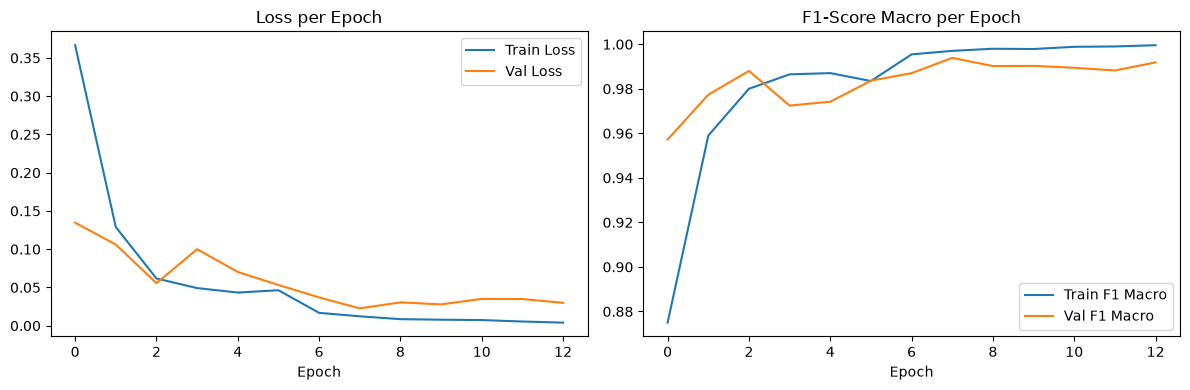

In [13]:
# Plot training curve: loss & F1 macro (train vs val)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(main_history["train_loss"], label="Train Loss")
axes[0].plot(main_history["val_loss"], label="Val Loss")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(main_history["train_f1"], label="Train F1 Macro")
axes[1].plot(main_history["val_f1"], label="Val F1 Macro")
axes[1].set_title("F1-Score Macro per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


> **Catatan interpretasi (isi manual):**
> - Apakah ada tanda overfitting (train F1 terus naik, val F1 stagnan/turun)?
> - Berapa gap antara baseline CNN vs model pretrained? Apakah transfer learning terbukti membantu?
> - Perlu adjustment: lebih banyak augmentasi, regularisasi tambahan, atau ganti arsitektur
>   (ResNet34/EfficientNet) kalau performa masih kurang?

## 8. Simpan Model Terbaik

Model checkpoint terbaik (`best_model.pt`) sudah otomatis tersimpan selama training loop
(berdasarkan Val F1 Macro tertinggi). Simpan juga history training untuk dokumentasi/laporan.

In [14]:
with open(os.path.join(ARTIFACT_DIR, "training_history.json"), "w") as f:
    json.dump({
        "baseline": baseline_history,
        "main_model": main_history,
        "best_val_f1": best_val_f1,
    }, f, indent=2)

print("Checkpoint model terbaik:", checkpoint_path)
print("History training tersimpan di:", os.path.join(ARTIFACT_DIR, "training_history.json"))
print(f"\nBest Val F1 Macro: {best_val_f1:.4f}")


Checkpoint model terbaik: ../artifacts\best_model.pt
History training tersimpan di: ../artifacts\training_history.json

Best Val F1 Macro: 0.9939


### Ringkasan Keputusan Modeling (untuk laporan/notebook final)

- **Baseline:** CNN sederhana dari awal (4 conv block + FC), dilatih {BASELINE_EPOCHS} epoch tanpa
  class weight, sebagai angka pembanding
- **Model utama:** ResNet18 pretrained ImageNet, full fine-tuning, dipilih karena dataset relatif
  kecil sehingga transfer learning membantu representasi fitur visual
- **Loss:** CrossEntropyLoss dengan class weight (inverse frequency) agar selaras dengan metrik
  F1 Macro dan tidak bias ke kelas mayoritas
- **Training:** Adam optimizer, LR scheduler (ReduceLROnPlateau berdasarkan Val F1), early stopping
  dengan patience, checkpoint otomatis menyimpan model Val F1 terbaik

**Lanjut ke:** `03_evaluation_interpretation.ipynb` — load `best_model.pt`, hitung F1 per-kelas,
confusion matrix, dan analisis error pada sampel yang salah prediksi.

In [15]:
import hashlib

def hash_images(df, img_dir):
    hashes = {}
    for img_id in df['image_id']:
        img_path = os.path.join(img_dir, img_id)
        with open(img_path, "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        hashes[img_id] = h
    return hashes

train_hashes = hash_images(train_split_df, TRAIN_IMG_DIR)
val_hashes = hash_images(val_split_df, TRAIN_IMG_DIR)

train_hash_set = set(train_hashes.values())
val_hash_set = set(val_hashes.values())

overlap = train_hash_set & val_hash_set
print(f"Jumlah hash gambar yang SAMA PERSIS antara train dan val: {len(overlap)}")

# Cek juga near-duplicate dalam SATU set (train) — kalau banyak duplikat internal,
# artinya split acak besar kemungkinan menaruh "kembar"-nya di val
from collections import Counter
all_hashes = list(train_hashes.values()) + list(val_hashes.values())
hash_counts = Counter(all_hashes)
duplicated_hashes = {h: c for h, c in hash_counts.items() if c > 1}
print(f"Jumlah gambar (hash) yang muncul lebih dari 1x di seluruh dataset: {len(duplicated_hashes)}")

Jumlah hash gambar yang SAMA PERSIS antara train dan val: 0
Jumlah gambar (hash) yang muncul lebih dari 1x di seluruh dataset: 0
